Intro:
The purpose of this code is to compare a cubic spline, polynomial, and linear least squares fit on a dataset consisting of quarterly US GDP growth data. The dataset only includes selected quarters and ranges from 2010 Q1 to 2023 Q3. The source of the dataset is the U.S Bureau of Economic Analysis. A natural cubic spline, solved using a tridiagonal matrix, thomas algorthim, and a final function that uses the outputs of the previous two functions to construct the cubic spline will be used to interpolate the data set. A degree-4 polynomial will also be fit to the dataset and compared to the cubic spline fit as well as a linear least squares fit. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56], dtype=float)

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3], dtype=float)

full_x = np.arange(1, 57)

x_no_covid = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 49, 54, 56], dtype=float)

y_no_covid = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3], dtype=float)


Import libraries, make arrays for x and y components as well as the x and y with the covid quarters excluded

In [2]:
def least_squares(x, y):
    n = len(x)

    m = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - (np.sum(x))**2)
    c = (np.sum(y) - m * np.sum(x)) / n

    return m, c

In [3]:
def evaluate_spline(x_data, y_data, M, x_query):

    n = len(x_data)
    h = np.diff(x_data)  # step sizes

    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2)  # find interval

    hi = h[i]
    dx_left = x_query - x_data[i]  # (x - x_i)
    dx_right = x_data[i+1] - x_query  # (x_{i+1} - x)
    S = ((M[i] / (6*hi)) * dx_right**3 + (M[i+1] / (6*hi)) * dx_left**3 + (y_data[i]/hi - M[i] *hi/6) * dx_right + (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left)

    return S

In [4]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1] # Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * (((y[i + 1] - y[i]) / h[i]) - ((y[i] - y[i - 1]) / h[i - 1])) # Right-hand side vector
    
    return A, B, C, D

function to setup the tridiagonal matrix, x and y are points getting fit

In [5]:
def thomas_algorithm(a, b, c, d):
    
    a = np.array(a, dtype=float).copy()
    b = np.array(b, dtype=float).copy()
    c = np.array(c, dtype=float).copy()
    d = np.array(d, dtype=float).copy()
    n = len(b)
    
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
        # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
            
    return x

function that evaluates tridiagonal matrix using thomas algorithm

In [6]:
def vandermonde_matrix(x, degree):
    n = len(x)
    V = np.zeros((n, degree + 1))

    for i in range(n):
        for j in range(degree + 1):
            V[i, j] = x[i] ** j

    return V

function that evaluates vandermonde matrix taking in an array and the degree

In [7]:
def poly_fit_coefficients(x, y, degree):
    V = vandermonde_matrix(x, degree)
    A = V.T @ V
    b = V.T @ y
    coefficients = np.linalg.solve(A, b)
    return coefficients

function that gets the coefficients for the polynomial fit and calls the vandermonde matrix solver function

In [8]:
def polyval(coeffs, x_values):
    x_values = np.array(x_values, dtype=float)
    y_values = np.zeros_like(x_values, dtype=float)

    for j in range(len(coeffs)):
        y_values += coeffs[j] * x_values ** j

    return y_values

In [9]:
def rmse(y_act, y_fit):
    return np.sqrt(np.mean((y_act - y_fit) ** 2))

function that calculates rmse given actual y value and the fit y

In [10]:
A, B, C, D = setup_tridiagonal_matrix(x, y)

a = A[1:]
b = B.copy()
c = C[:-1]
d = D.copy()

M2 = thomas_algorithm(a, b, c, d)

M = np.zeros(len(x))
M[1:-1] = M2

cubic_spline_values = evaluate_spline(x, y, M, full_x)

poly_coefficients = poly_fit_coefficients(x, y, 4)
polyfit_values = polyval(poly_coefficients, full_x)
polyfit_values_points = polyval(poly_coefficients, x)
poly_residuals = y - polyfit_values_points

Evaluate cubicspline and polyfit using functions above

In [11]:
m, c_lstsq = least_squares(x_no_covid, y_no_covid)
lstsq_values = m * full_x + c_lstsq
lstsq_values_points = m * x_no_covid + c_lstsq
lstsq_residuals = y_no_covid - lstsq_values_points

Fit a least squares linear model to the data set excluding the covid quarters

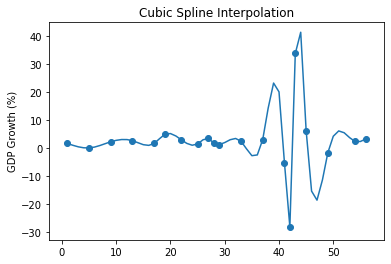

In [12]:
plt.figure()
plt.plot(full_x, cubic_spline_values)
plt.scatter(x, y)
plt.ylabel("GDP Growth (%)")
plt.title("Cubic Spline Interpolation")
plt.show()

Part A:
I used a natural cubic spline which is forced to pass through all 20 points. The system consists of 18 second derivatives as the first and last second derivative are both zero (the splines ends). The spline, first derivative, and second derivative all must be continuous at each interior knot. The boundary conditions are that the second derivative is zero at both ends. The plot of the cubic spline is smooth due to the first and second derivatives having to be continuous; however, it isn't fitting the dataset in a useful way as its forced to pass through every point. It is a reasonable interpolatio as the spline is smooth between points of the dataset but is not useful due to one of the constrains of an interpolation being that the spline must pass through every point on the dataset. The cubic spline mostly avoids the runge phenomenon as the oscilation near the right end of the graph is caused by the points in the dataset varying significantly. Interpolations are good for estimating what occurs between points but fail to accurately show the trend of the graph when there are extreme outliers as they must pass through those outliers thus decreasing the accuracy in showing the overall trend. Smoothing the spline would be preferable here as it would better estimate the trend of the graph. 

polynomial coefficients= [ 2.11403340e-01  4.12733208e-01 -2.11036921e-02  3.57892276e-04
 -1.71060095e-06] 

polynomial RMSE = 10.031440678677116 

least squares RMSE = 1.4431864883291987 

least squares slope = -0.001906988188976378


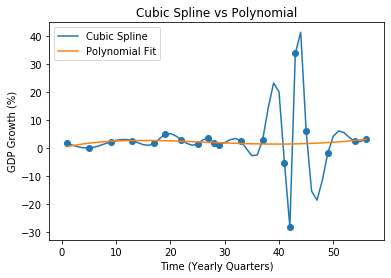

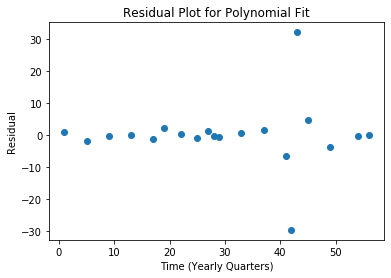

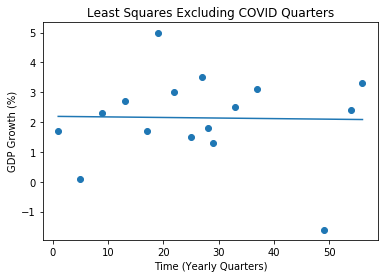

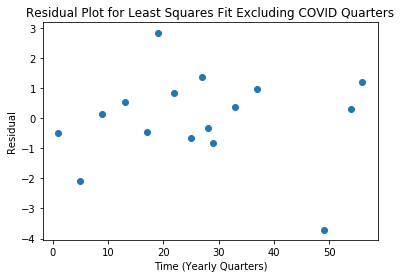

In [13]:
print("polynomial coefficients=", poly_coefficients, "\n")
print("polynomial RMSE =", rmse(y, polyfit_values_points), "\n")
print("least squares RMSE =", rmse(y_no_covid, lstsq_values_points), "\n")
print("least squares slope =", m)

plt.figure()
plt.plot(full_x, cubic_spline_values, label="Cubic Spline")
plt.plot(full_x, polyfit_values, label="Polynomial Fit")
plt.scatter(x, y)
plt.ylabel("GDP Growth (%)")
plt.title("Cubic Spline vs Polynomial")
plt.xlabel("Time (Yearly Quarters)")
plt.legend()
plt.show()

plt.figure()
plt.scatter(x, poly_residuals)
plt.title("Residual Plot for Polynomial Fit")
plt.ylabel("Residual")
plt.xlabel("Time (Yearly Quarters)")
plt.show()

plt.figure()
plt.scatter(x_no_covid, y_no_covid)
plt.plot(full_x, lstsq_values)
plt.ylabel("GDP Growth (%)")
plt.xlabel("Time (Yearly Quarters)")
plt.title("Least Squares Excluding COVID Quarters")
plt.show()

plt.figure()
plt.scatter(x_no_covid, lstsq_residuals)
plt.title("Residual Plot for Least Squares Fit Excluding COVID Quarters")
plt.xlabel("Time (Yearly Quarters)")
plt.ylabel("Residual")
plt.show()

Part B:
The polynomial better captures the overall trend of the graph as it does not have extreme oscillations around the covid quarters like the cubic spline does. As for reproducing specific data points, the cubic spline has the edge as it interpolates each point exactly. This is shown in the RMSE of the polynomial fit being 10 which is very high on this graph. This is due to it being very far from the outlier data points as it smooths through them. The tradeoff between interpolations and approximations is that approximations will represent an overall trend while not reacting to outliers while an interpolation will react to all outliers and is a less smooth representation of the overall trend and better for estimating outcomes between data points. The slope of the linear least squares is nearly zero, since there is a lot of variation between points the linear least squares fit is a poor model as it does not capture the up and down variations point to point. While its RMSE is less than the polyfit at 1.44, this is only because the COVID quarters were excluded. This model really only shows a very long term either upwards, downwards, or flat trend. The model assumes that the relationship between GDP growth and time is linear which it is not as GDP growth varies year to year. 

Part C:
A cubic spline should be used over a polynomial fit to interpolate between two known datapoints. This is because it has a few advantages over the polynomial: its end points are on the two data points, its less sensitive to global outliers, its more effected by local points than the entire graph, and its forced to be smooth. It only fails around the COVID outliers because those points are so extreme. A polynomial fit is less suited to estimating what occurs between points and more suited towards longer time trends. 

Conclusion:
For interpolation, cubic spline was best as its forced to go through every single point. For trend analysis, polyfit was best as its less effected by outliers when estimating the overall trend. The limitations of cubic spline are that it suffers when examing the overall trend when there are outliers, for polynomial fit, its bad for interpolating between points and for the linear least squares fit its only useful when the relationship between the two sets of data is linear or when looking at trends over a long period of data. 